# Heart Failure Patient Mortality Risk Analysis

**Author:** Rishikesh Munnaluri

This notebook analyzes clinical records of patients with heart failure and builds machine-learning models to predict the recorded `DEATH_EVENT`.

> The target represents mortality during the follow-up period among patients who already had heart failure. It does not predict whether a healthy person will develop heart failure.

<p align="center">
  <img src="img.png" width="700">
</p>

## Objective

The notebook will:

1. validate and explore the dataset;
2. examine relationships between clinical features and mortality;
3. train multiple classification models;
4. compare accuracy, precision, recall, F1-score and ROC-AUC;
5. evaluate the effect of the follow-up `time` feature separately.

**Medical disclaimer:** This project is for educational and research purposes only. It is not a diagnostic tool and must not be used for clinical decisions.

<p align="center">
  <img src="img2.png" width="700">
</p>

## 1. Setup

In [6]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET = "DEATH_EVENT"
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/"
    "heart_failure_clinical_records_dataset.csv"
)

## 2. Load and validate the data

The notebook first searches for the CSV beside the notebook and inside a `data/` folder. If it is not found, it attempts to load the dataset from UCI.

In [7]:
candidate_paths = [
    Path("heart_failure_clinical_records_dataset.csv"),
    Path("data/heart_failure_clinical_records_dataset.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    print(f"Loaded dataset from: {data_path.resolve()}")
else:
    try:
        df = pd.read_csv(DATA_URL)
        print("Loaded dataset from the UCI Machine Learning Repository.")
    except Exception as exc:
        raise FileNotFoundError(
            "Dataset not found. Place 'heart_failure_clinical_records_dataset.csv' "
            "beside this notebook or inside a data/ folder."
        ) from exc

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded dataset from the UCI Machine Learning Repository.
Dataset shape: 299 rows × 13 columns


In [8]:
expected_columns = {
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "sex",
    "smoking",
    "time",
    "DEATH_EVENT",
}

missing_columns = expected_columns.difference(df.columns)

if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

df = df.copy()
display(df.head())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 3. Data-quality checks

In [9]:
quality_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(),
})

display(quality_summary)
print(f"Duplicate rows: {df.duplicated().sum()}")

,data_type,missing_values,unique_values
age,float64,0,47
anaemia,int64,0,2
creatinine_phosphokinase,int64,0,208
diabetes,int64,0,2
ejection_fraction,int64,0,17
high_blood_pressure,int64,0,2
platelets,float64,0,176
serum_creatinine,float64,0,40
serum_sodium,int64,0,27
sex,int64,0,2


Duplicate rows: 0


In [10]:
display(df.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.83,11.89,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.43,0.50,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.84,970.29,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.42,0.49,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.08,11.83,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.35,0.48,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.03,97804.24,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.39,1.03,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.63,4.41,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.65,0.48,0.0,0.0,1.0,1.0,1.0


In [11]:
target_summary = (
    df[TARGET]
    .value_counts()
    .rename(index={0: "Alive", 1: "Death"})
    .to_frame("count")
)
target_summary["percentage"] = (
    target_summary["count"] / len(df) * 100
).round(2)

display(target_summary)

,count,percentage
DEATH_EVENT,,
Alive,203,67.89
Death,96,32.11


### Outlier handling decision

The dataset contains extreme laboratory values. These records are retained because an unusual clinical measurement is not automatically an error, and deleting high-risk patients could distort the analysis. Models that require scaling use a pipeline so preprocessing is learned only from training data.

In [12]:
numeric_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time",
]

distribution_summary = pd.DataFrame({
    "skewness": df[numeric_features].skew(),
    "minimum": df[numeric_features].min(),
    "median": df[numeric_features].median(),
    "maximum": df[numeric_features].max(),
}).round(2)

display(distribution_summary)

,skewness,minimum,median,maximum
age,0.42,40.0,60.0,95.0
creatinine_phosphokinase,4.46,23.0,250.0,7861.0
ejection_fraction,0.56,14.0,38.0,80.0
platelets,1.46,25100.0,262000.0,850000.0
serum_creatinine,4.46,0.5,1.1,9.4
serum_sodium,-1.05,113.0,137.0,148.0
time,0.13,4.0,115.0,285.0


## 4. Exploratory data analysis

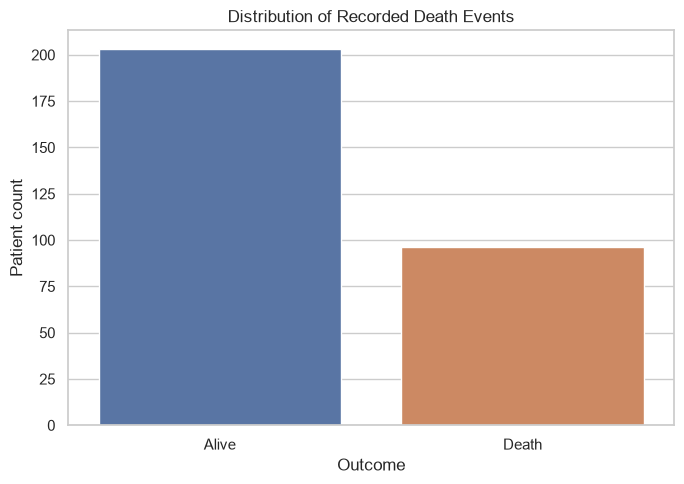

In [13]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=TARGET, hue=TARGET, legend=False)
plt.xticks([0, 1], ["Alive", "Death"])
plt.xlabel("Outcome")
plt.ylabel("Patient count")
plt.title("Distribution of Recorded Death Events")
plt.tight_layout()
plt.show()

In [14]:
binary_features = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking",
]

mortality_by_binary_feature = pd.concat(
    {
        feature: df.groupby(feature)[TARGET].mean()
        for feature in binary_features
    },
    names=["feature", "value"],
).reset_index(name="mortality_rate")

mortality_by_binary_feature["mortality_rate"] *= 100
display(mortality_by_binary_feature.round(2))

,feature,value,mortality_rate
0,anaemia,0,29.41
1,anaemia,1,35.66
2,diabetes,0,32.18
3,diabetes,1,32.00
4,high_blood_pressure,0,29.38
5,high_blood_pressure,1,37.14
6,sex,0,32.38
7,sex,1,31.96
8,smoking,0,32.51
9,smoking,1,31.25


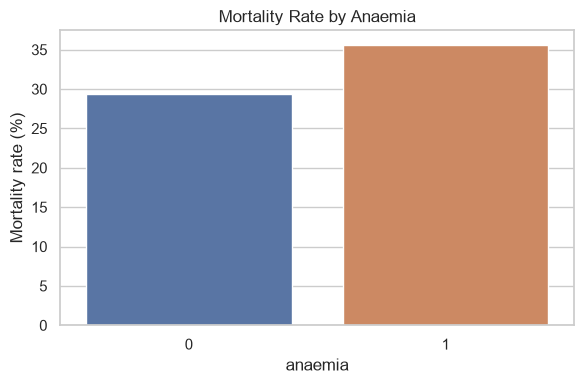

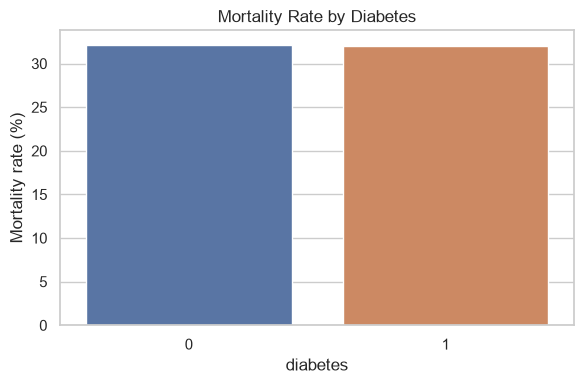

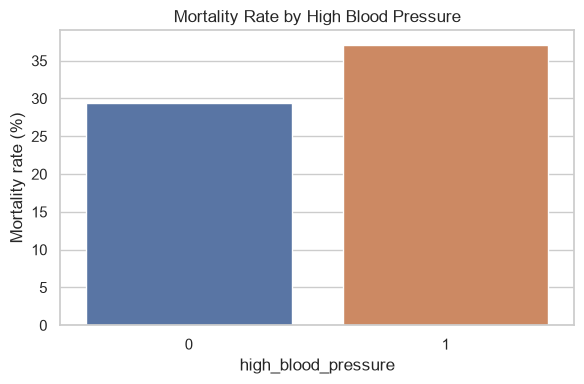

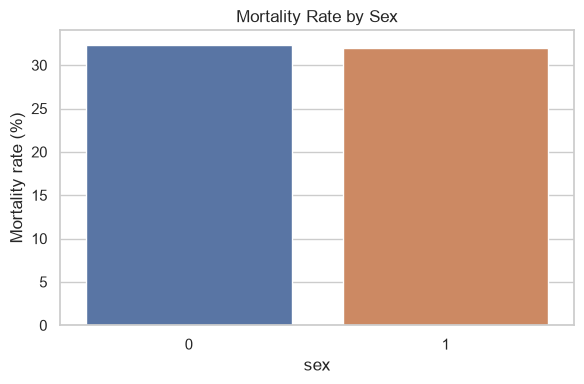

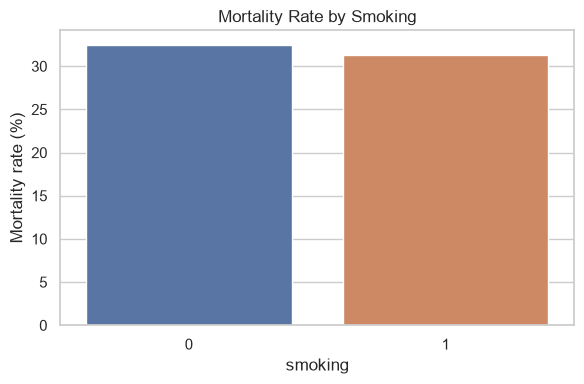

In [15]:
for feature in binary_features:
    plot_data = (
        df.groupby(feature, as_index=False)[TARGET]
        .mean()
        .assign(**{TARGET: lambda data: data[TARGET] * 100})
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=plot_data,
        x=feature,
        y=TARGET,
        hue=feature,
        legend=False,
    )
    plt.ylabel("Mortality rate (%)")
    plt.title(f"Mortality Rate by {feature.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()

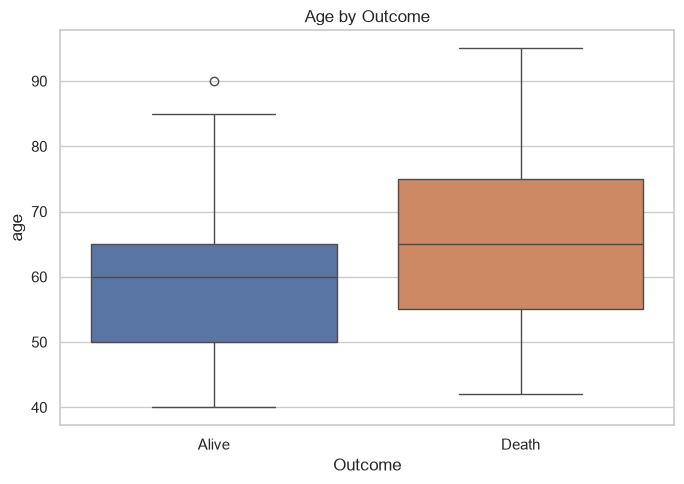

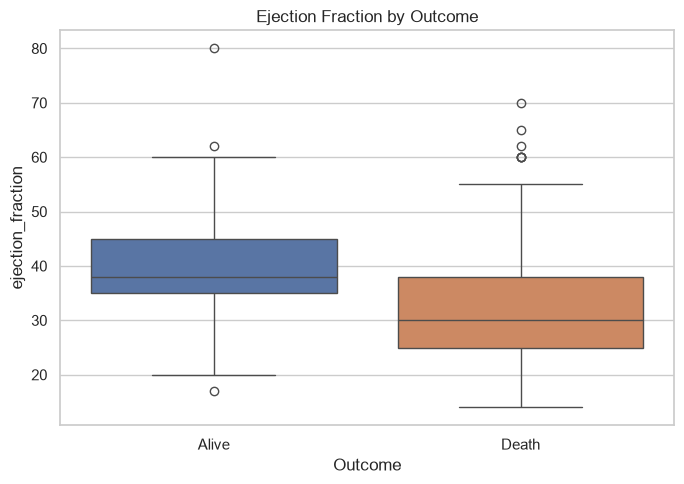

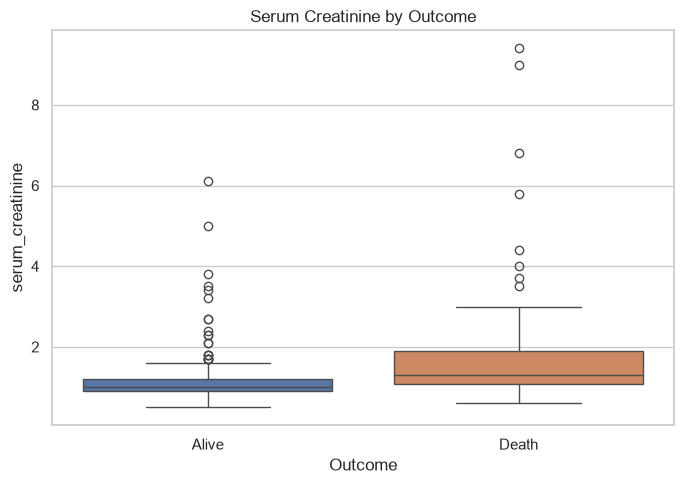

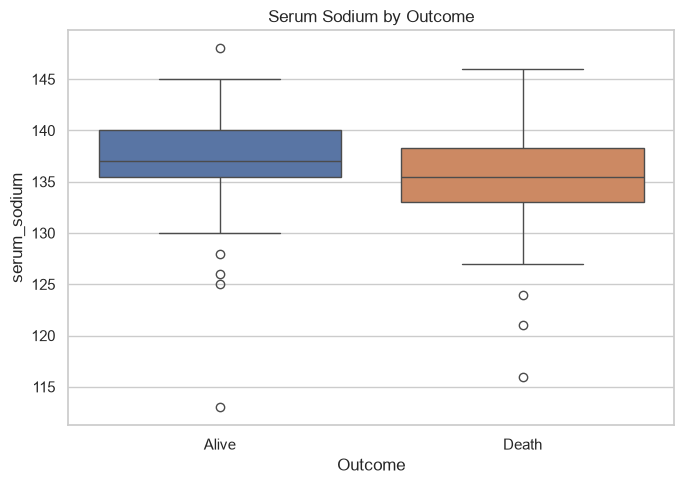

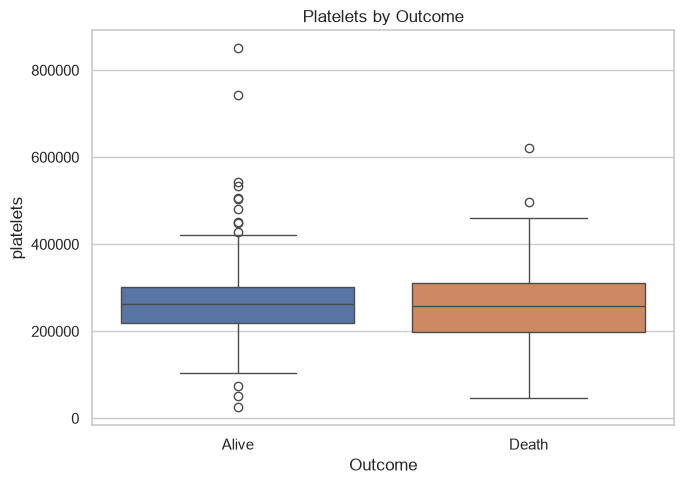

In [16]:
key_numeric_features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "platelets",
]

for feature in key_numeric_features:
    plt.figure(figsize=(7, 5))
    sns.boxplot(
        data=df,
        x=TARGET,
        y=feature,
        hue=TARGET,
        legend=False,
    )
    plt.xticks([0, 1], ["Alive", "Death"])
    plt.xlabel("Outcome")
    plt.title(f"{feature.replace('_', ' ').title()} by Outcome")
    plt.tight_layout()
    plt.show()

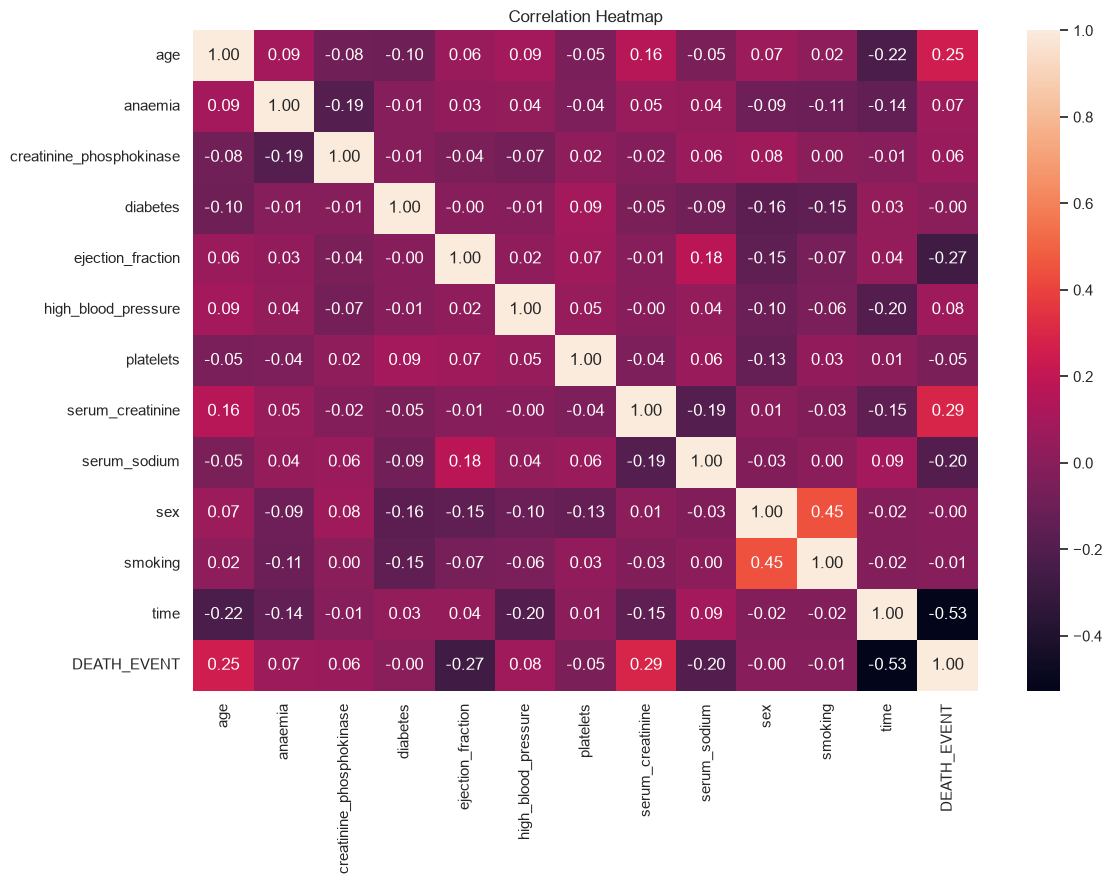

,correlation_with_death_event
time,-0.527
serum_creatinine,0.294
ejection_fraction,-0.269
age,0.254
serum_sodium,-0.195
high_blood_pressure,0.079
anaemia,0.066
creatinine_phosphokinase,0.063
platelets,-0.049
smoking,-0.013


In [17]:
plt.figure(figsize=(12, 9))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

display(
    correlation_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
    .to_frame("correlation_with_death_event")
    .round(3)
)

The plots and correlations describe associations in this dataset. They do not establish medical causation.

## 5. Machine-learning preparation

The primary models exclude `time`, because it is the follow-up duration and may not be known when a patient is first assessed. Its effect is tested separately later.

In [18]:
X = df.drop(columns=[TARGET, "time"])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print("Training target distribution:")
display(y_train.value_counts(normalize=True).sort_index().rename("proportion"))

Training rows: 239
Testing rows: 60
Training target distribution:


DEATH_EVENT
0    0.677824
1    0.322176
Name: proportion, dtype: float64

In [19]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

## 6. Train and compare models

In [20]:
results = []
fitted_models = {}
predictions = {}
probabilities = {}

for model_name, model in models.items():
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    y_pred = fitted_model.predict(X_test)
    y_probability = fitted_model.predict_proba(X_test)[:, 1]

    fitted_models[model_name] = fitted_model
    predictions[model_name] = y_pred
    probabilities[model_name] = y_probability

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_probability),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(["roc_auc", "recall"], ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(3))

,model,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,0.700,0.522,0.632,0.571,0.780
1,Gradient Boosting,0.717,0.571,0.421,0.485,0.750
2,Decision Tree,0.717,0.538,0.737,0.622,0.744
3,Logistic Regression,0.700,0.526,0.526,0.526,0.734


In [21]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cross_validation_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
    )

    cross_validation_results.append({
        "model": model_name,
        "mean_cv_roc_auc": scores.mean(),
        "std_cv_roc_auc": scores.std(),
    })

cv_results_df = (
    pd.DataFrame(cross_validation_results)
    .sort_values("mean_cv_roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df.round(3))

,model,mean_cv_roc_auc,std_cv_roc_auc
0,Random Forest,0.781,0.074
1,Logistic Regression,0.769,0.055
2,Gradient Boosting,0.724,0.079
3,Decision Tree,0.653,0.122


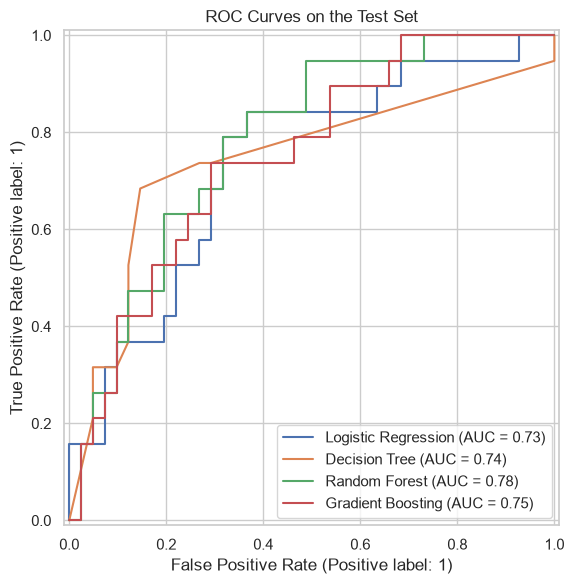

In [22]:
plt.figure(figsize=(8, 6))

for model_name in fitted_models:
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities[model_name],
        name=model_name,
        ax=plt.gca(),
    )

plt.title("ROC Curves on the Test Set")
plt.tight_layout()
plt.show()

## 7. Inspect the selected model

In [23]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_predictions = predictions[best_model_name]

print(f"Selected model by test ROC-AUC: {best_model_name}")
print()
print(classification_report(
    y_test,
    best_predictions,
    target_names=["Alive", "Death"],
    zero_division=0,
))

Selected model by test ROC-AUC: Random Forest

              precision    recall  f1-score   support

       Alive       0.81      0.73      0.77        41
       Death       0.52      0.63      0.57        19

    accuracy                           0.70        60
   macro avg       0.67      0.68      0.67        60
weighted avg       0.72      0.70      0.71        60



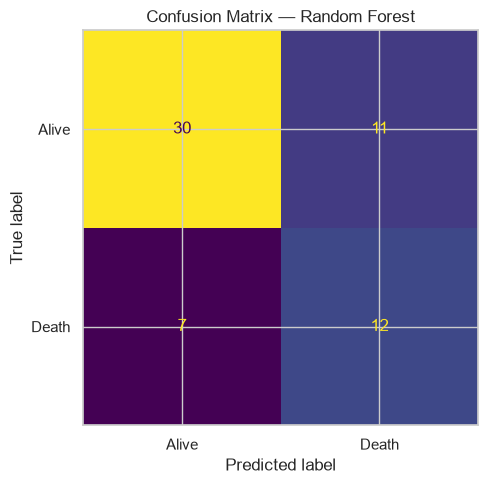

In [24]:
matrix = confusion_matrix(y_test, best_predictions)

figure, axis = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["Alive", "Death"],
).plot(ax=axis, values_format="d", colorbar=False)

axis.set_title(f"Confusion Matrix — {best_model_name}")
figure.tight_layout()
plt.show()

,feature,importance
0,serum_creatinine,0.2444
1,ejection_fraction,0.2031
2,creatinine_phosphokinase,0.1187
3,age,0.1182
4,platelets,0.1129
5,serum_sodium,0.0968
6,high_blood_pressure,0.0261
7,diabetes,0.0219
8,anaemia,0.0214
9,smoking,0.0193


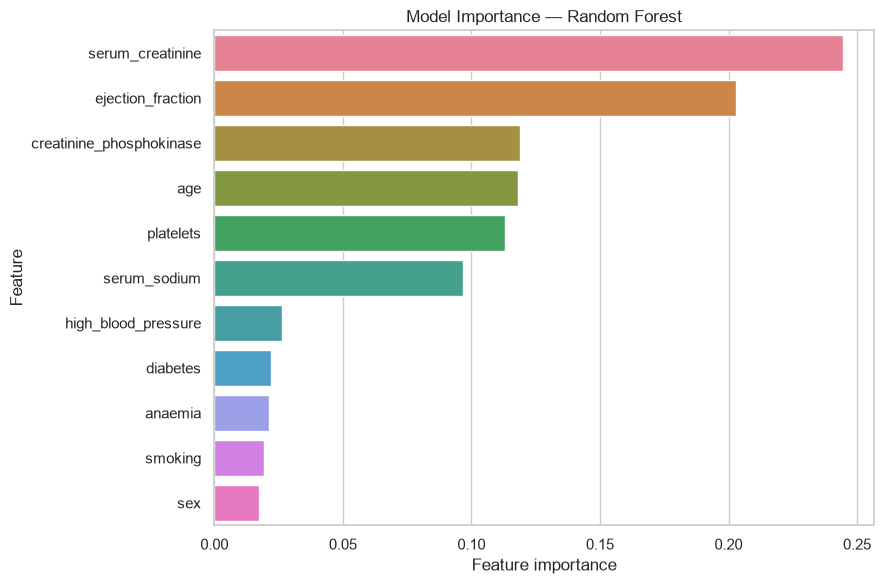

In [25]:
if isinstance(best_model, Pipeline):
    estimator = best_model.named_steps["model"]
else:
    estimator = best_model

if hasattr(estimator, "feature_importances_"):
    importance_values = estimator.feature_importances_
    importance_label = "Feature importance"
elif hasattr(estimator, "coef_"):
    importance_values = np.abs(estimator.coef_[0])
    importance_label = "Absolute coefficient"
else:
    importance_values = None

if importance_values is not None:
    importance_df = (
        pd.DataFrame({
            "feature": X.columns,
            "importance": importance_values,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(importance_df.round(4))

    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=importance_df,
        x="importance",
        y="feature",
        hue="feature",
        legend=False,
    )
    plt.xlabel(importance_label)
    plt.ylabel("Feature")
    plt.title(f"Model Importance — {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("The selected estimator does not expose direct feature importance.")

Feature importance is model-specific and should not be interpreted as proof that a feature medically causes mortality.

## 8. Sensitivity check: including follow-up time

This check demonstrates how strongly performance changes when `time` is included. The result should be interpreted cautiously because follow-up duration may not be available at the intended prediction point.

In [26]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

feature_sets = {
    "Without time": df.drop(columns=[TARGET, "time"]),
    "With time": df.drop(columns=[TARGET]),
}

time_comparison = []

for feature_set_name, feature_data in feature_sets.items():
    scores = cross_val_score(
        logistic_model,
        feature_data,
        y,
        cv=cv,
        scoring="roc_auc",
    )

    time_comparison.append({
        "feature_set": feature_set_name,
        "mean_cv_roc_auc": scores.mean(),
        "std_cv_roc_auc": scores.std(),
    })

time_comparison_df = pd.DataFrame(time_comparison)
display(time_comparison_df.round(3))

,feature_set,mean_cv_roc_auc,std_cv_roc_auc
0,Without time,0.769,0.055
1,With time,0.877,0.033


## 9. Final result and limitations

In [27]:
best_result = results_df.iloc[0]
best_cv_result = cv_results_df.iloc[0]

print(
    f"Best test-set model: {best_result['model']}\n"
    f"Test ROC-AUC: {best_result['roc_auc']:.3f}\n"
    f"Test recall for recorded deaths: {best_result['recall']:.3f}\n"
    f"Test F1-score: {best_result['f1_score']:.3f}\n\n"
    f"Best mean cross-validated ROC-AUC: "
    f"{best_cv_result['mean_cv_roc_auc']:.3f} "
    f"(± {best_cv_result['std_cv_roc_auc']:.3f}) "
    f"using {best_cv_result['model']}."
)

Best test-set model: Random Forest
Test ROC-AUC: 0.780
Test recall for recorded deaths: 0.632
Test F1-score: 0.571

Best mean cross-validated ROC-AUC: 0.781 (± 0.074) using Random Forest.


### Limitations

- The dataset contains only 299 patient records, so performance estimates can vary across splits.
- The records concern patients who already had heart failure.
- The dataset is observational; associations and model importance do not establish causality.
- Clinical thresholds were not used to delete records.
- External validation on a larger and independent dataset is required before any real-world use.
- This notebook is an educational analysis, not a medical product.

### Dataset source

Heart Failure Clinical Records, UCI Machine Learning Repository:  
https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records